### **IRIS Exploratory Data Analysis**

### 1. Import Modules

In [139]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

### 2. Load Dataset

In [140]:
df = pd.read_csv("data/Iris.csv")

### 3. Dataset Overview

#### Dataset Shape

In [141]:
print(df.shape)

(150, 6)


#### First Five Records

In [142]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


#### Dataset Information

In [143]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


#### Statistical Summary

In [144]:
print(df.describe())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


### 4. Missing Values

In [145]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


### 5. Duplicate Records

In [146]:
df.duplicated().sum()

0

#### Remove duplicates if any

In [147]:
df = df.drop_duplicates()

### 6. Class Distribution

In [148]:
print(df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


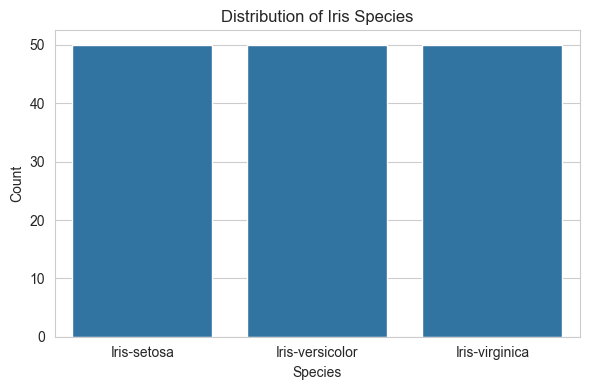

In [149]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Species')
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 7. Pairwise Relationships

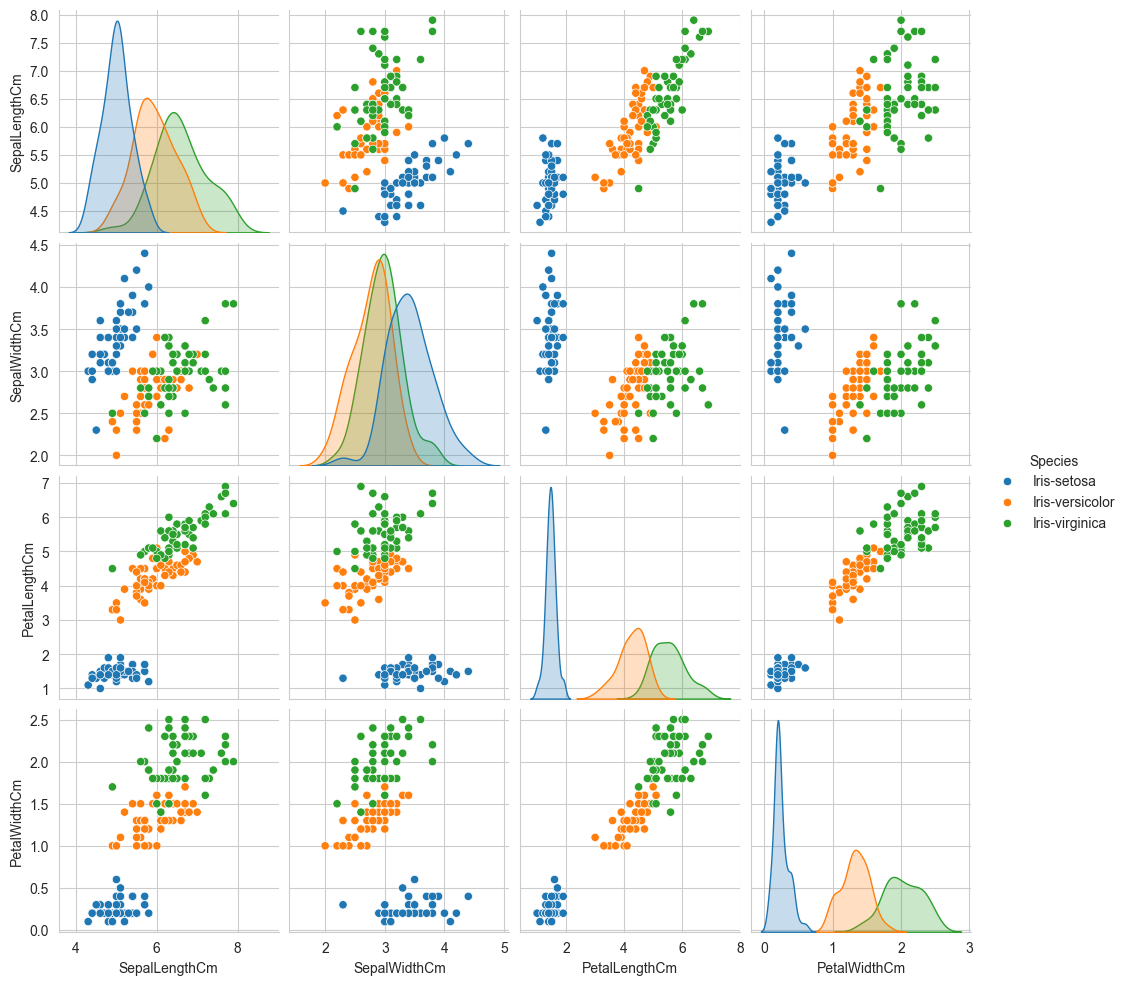

In [150]:
pair_df = df.drop('Id', axis=1)

sns.pairplot(
    pair_df,
    hue='Species',
    diag_kind='kde',
    height=2.5
)

plt.show()

### 8. Scatter Plot Analysis

#### Sepal Features

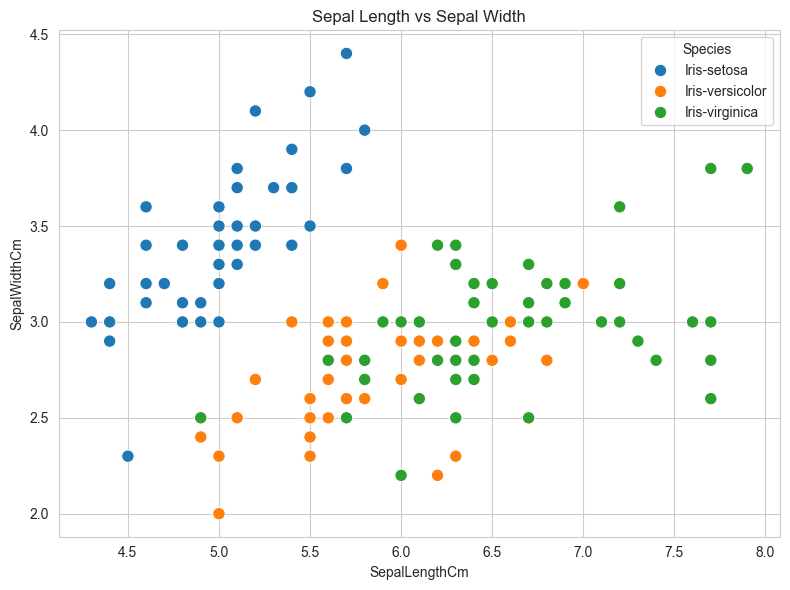

In [151]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species',
    s=80
)

plt.title("Sepal Length vs Sepal Width")
plt.tight_layout()
plt.show()

#### Petal Features

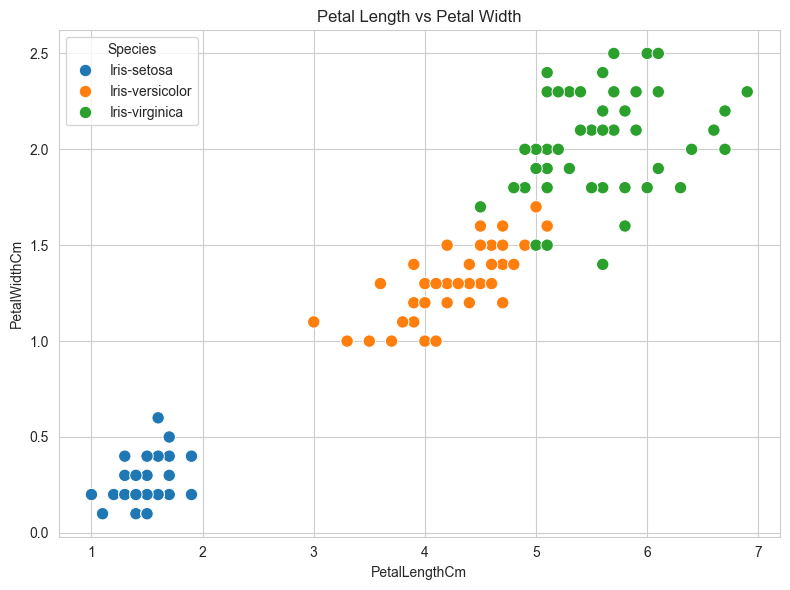

In [152]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.tight_layout()
plt.show()

### 9. Feature Distributions

In [153]:
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

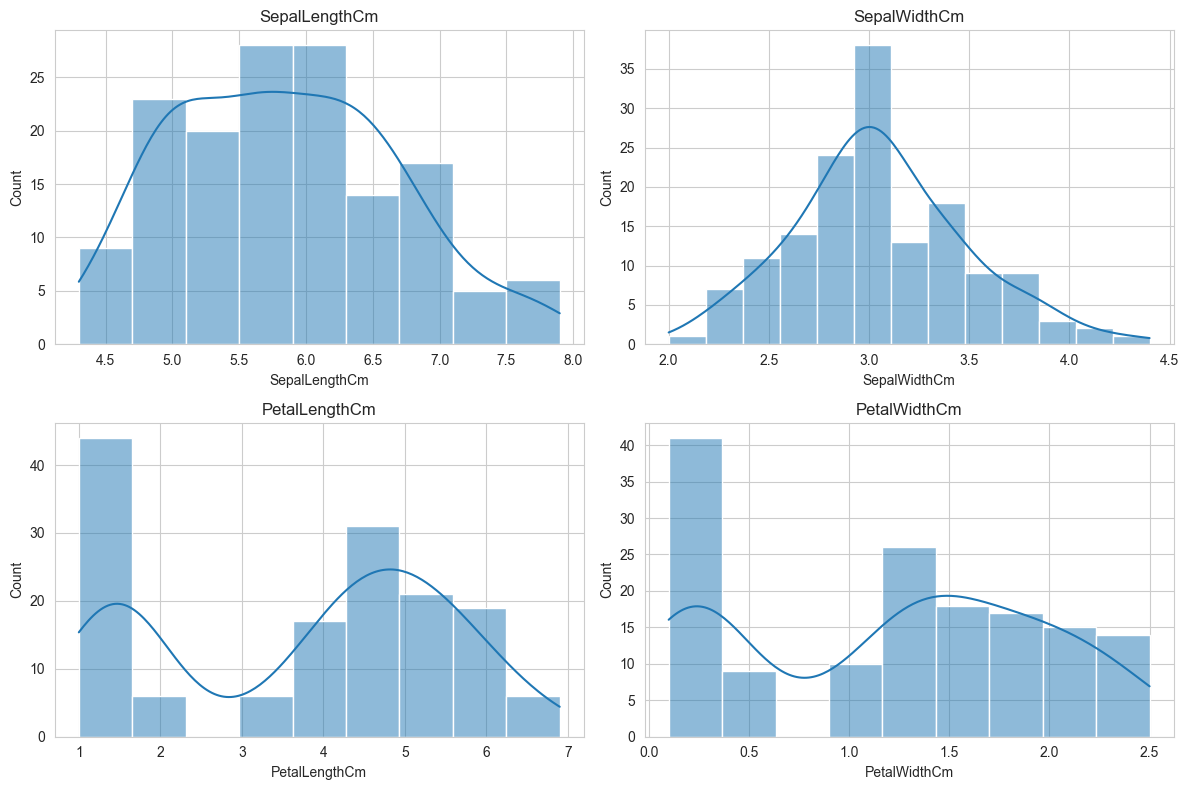

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

### 10. Species-wise Density Plot

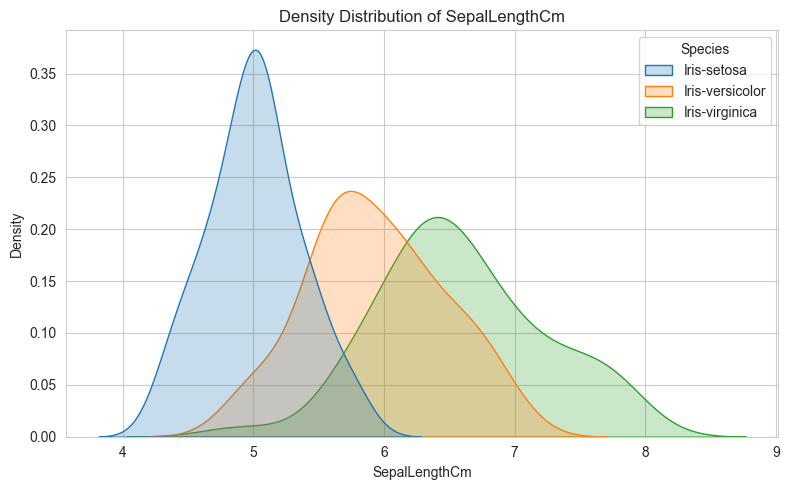

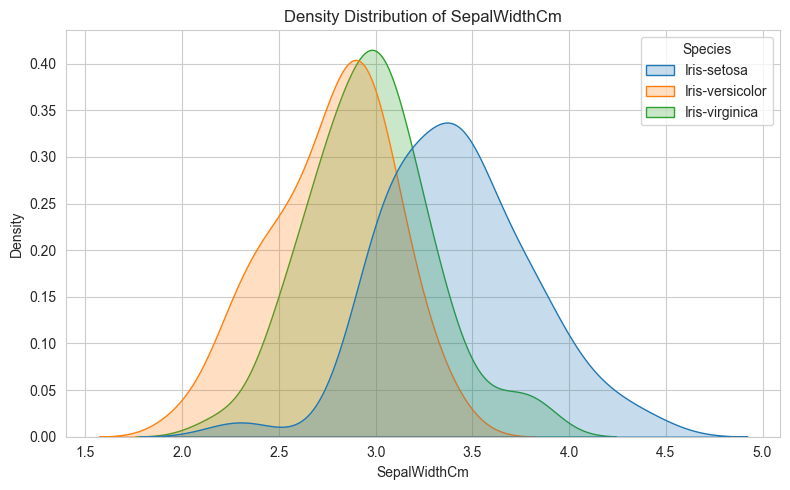

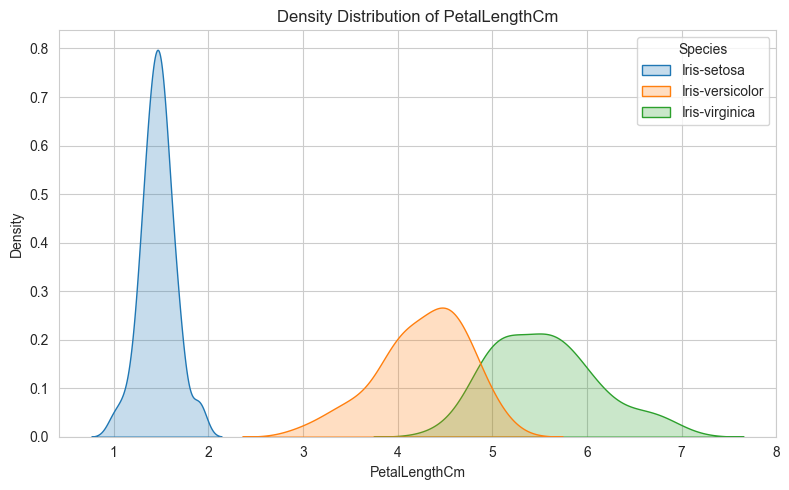

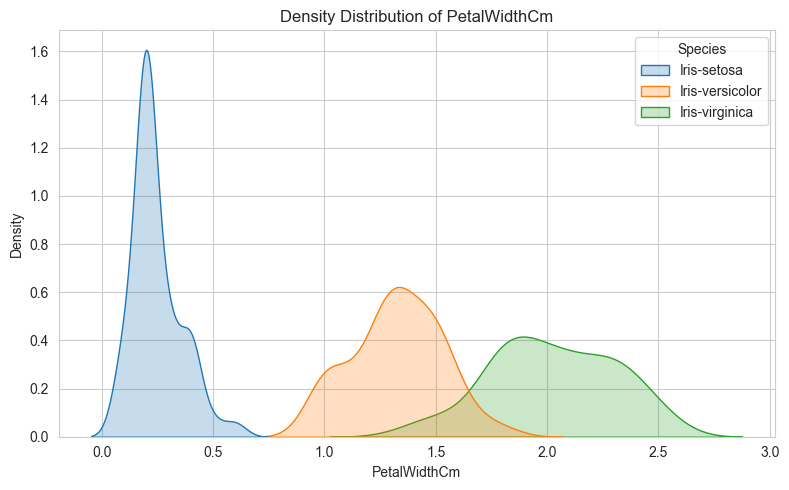

In [155]:
for feature in features:

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=feature,
        hue='Species',
        fill=True
    )

    plt.title(f"Density Distribution of {feature}")
    plt.tight_layout()
    plt.show()

### 11. Correlation Analysis


Correlation Matrix
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


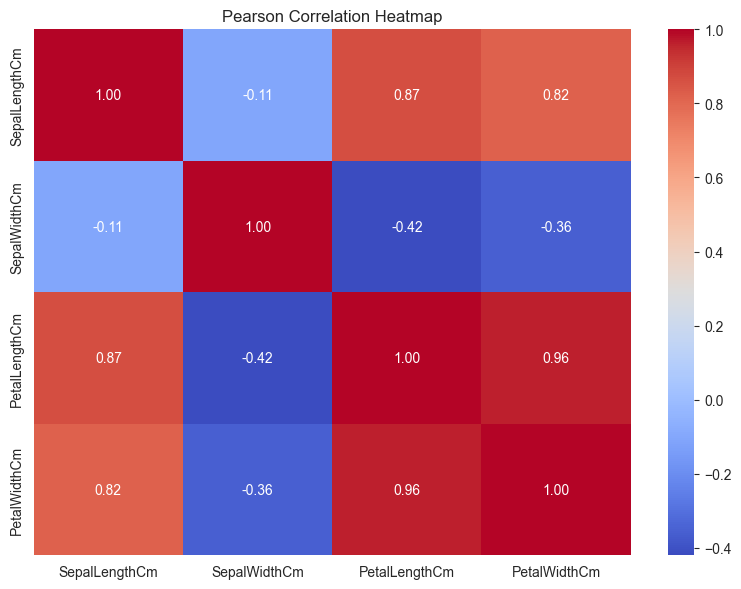

In [156]:
corr_matrix = (
    df.select_dtypes(include=np.number)
      .drop('Id', axis=1)
      .corr(method='pearson')
)

print("\nCorrelation Matrix")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

### 12. Boxplot Analysis

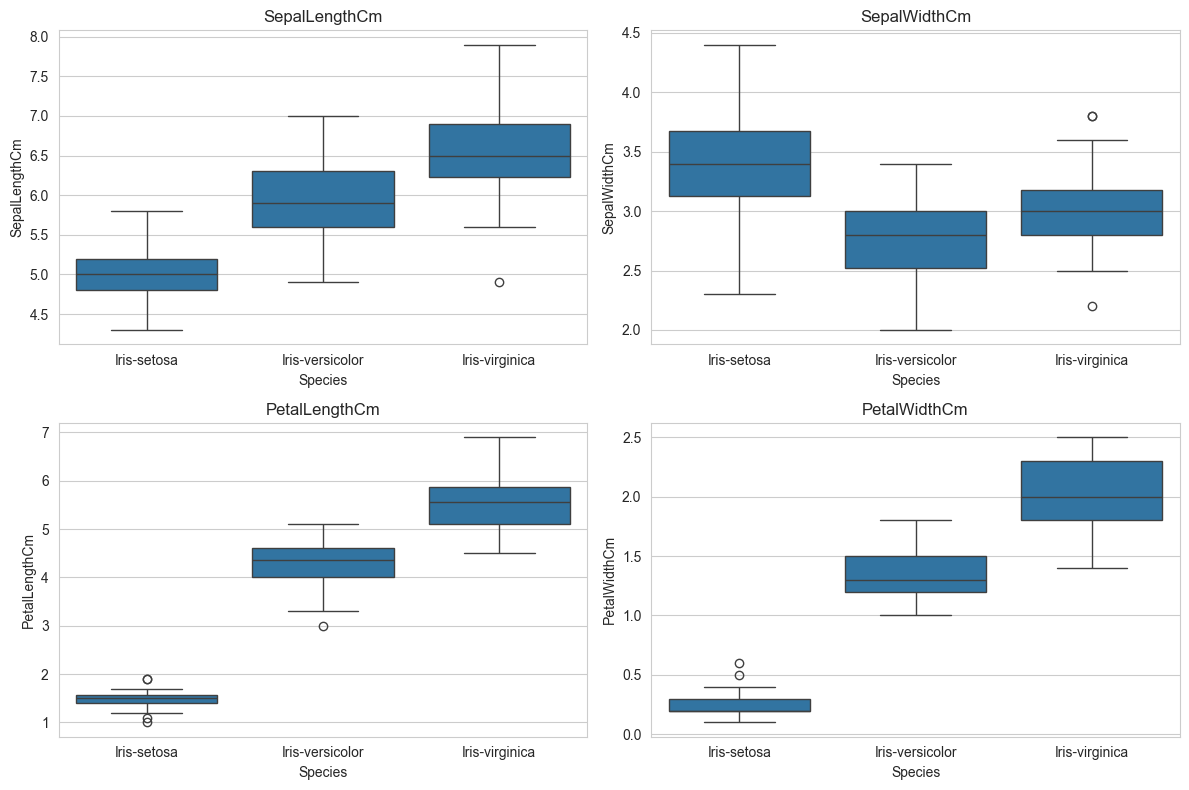

In [157]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        data=df,
        x='Species',
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

### 13. Outlier Detection using IQR

In [158]:
print("Outlier Analysis")

for col in features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Outlier Analysis
SepalLengthCm: 0 outliers
SepalWidthCm: 4 outliers
PetalLengthCm: 0 outliers
PetalWidthCm: 0 outliers


### 14. Remove Outliers

In [159]:
Q1 = df['SepalWidthCm'].quantile(0.25)
Q3 = df['SepalWidthCm'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df['SepalWidthCm'] >= lower_bound) &
    (df['SepalWidthCm'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("New Shape:", df_clean.shape)

Original Shape: (150, 6)
New Shape: (146, 6)


### 15. Final Dataset Shape

In [160]:
print(df_clean.shape)

(146, 6)


### 16. Feature Selection

In [161]:
X = df_clean.drop(['Id','Species'], axis=1)
y = df_clean['Species']

### 17. Encode Target Variable

In [162]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Classes:")
print(encoder.classes_)

Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


### 19. Train Test Split

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 20. Feature Scaling

In [164]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### ML Models

### 21. Logistic Regression

Logistic Regression Accuracy: 93.33

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



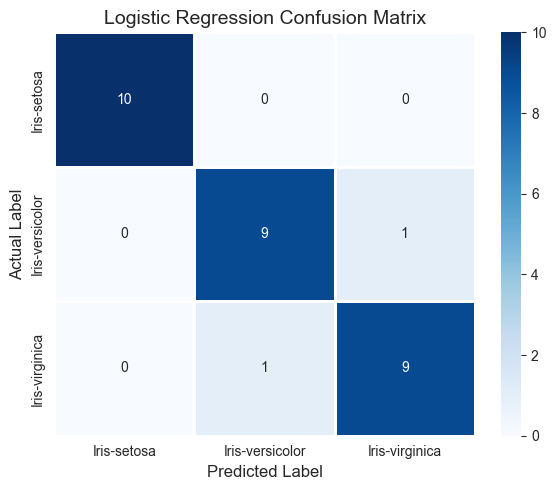

In [165]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc*100, 2))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

cm_log = confusion_matrix(y_test, lr_pred)

class_names = encoder.classes_   # ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()
plt.show()

### 22. K-Nearest Neighbors

KNN Accuracy: 86.67

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.80      0.80      0.80        10
           2       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



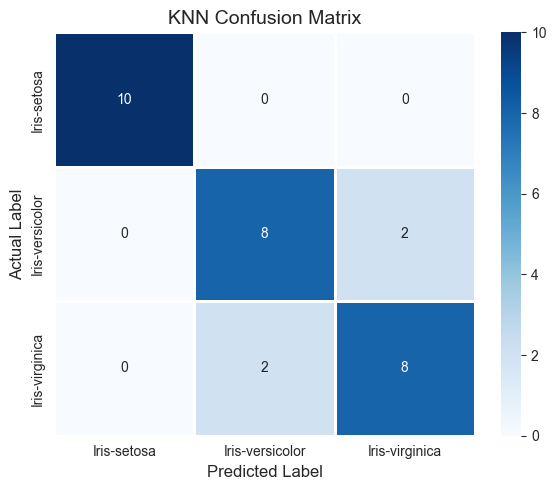

In [166]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", round(knn_acc*100, 2))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

cm_knn = confusion_matrix(y_test, knn_pred)

class_names = encoder.classes_   # ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("KNN Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()
plt.show()

### 23. Random Forest Classifier

Random Forest Accuracy: 93.33

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



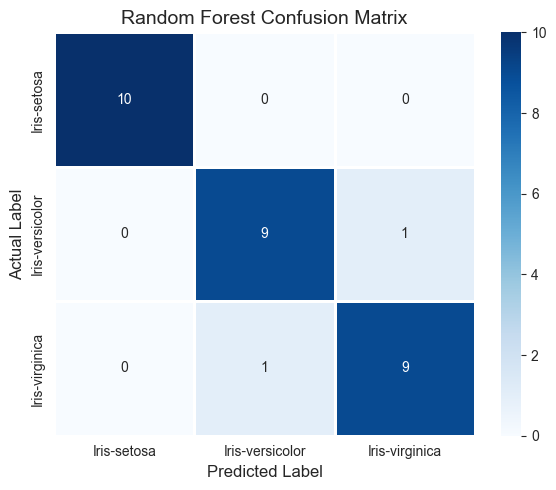

In [167]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc*100, 2))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

cm_rf = confusion_matrix(y_test, rf_pred)

class_names = encoder.classes_   # ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()
plt.show()

### 24. Model Comparison

In [168]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        knn_acc,
        rf_acc
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy
0  Logistic Regression  0.933333
2        Random Forest  0.933333
1                  KNN  0.866667


### 25. Accuracy Comparison Chart

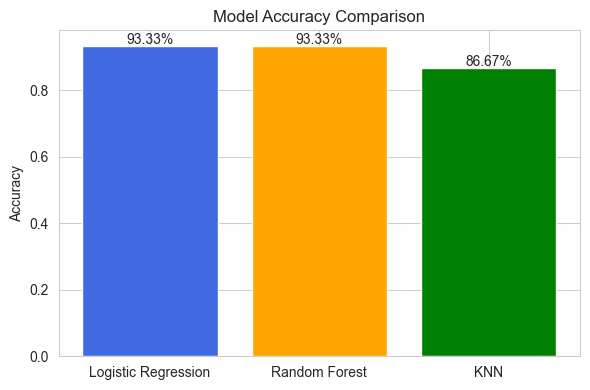

In [169]:
plt.figure(figsize=(6,4))

bars = plt.bar(results["Model"], results["Accuracy"], color=["royalblue", "orange", "green"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height()*100:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 26. Select Best Model

In [170]:
accuracy_dict = {

    "Logistic Regression": lr_acc,
    "KNN": knn_acc,
    "Random Forest": rf_acc

}

best_model_name = max(
    accuracy_dict,
    key=accuracy_dict.get
)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


### 27. Save Best Model

In [171]:
if best_model_name == "Logistic Regression":
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42))
    ])
    
    pipeline.fit(X, y)
    
    joblib.dump(pipeline, "best_iris_model.pkl")


elif best_model_name == "KNN":
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
    
    pipeline.fit(X, y)
    
    joblib.dump(pipeline, "best_iris_model.pkl")


else:
    
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(X, y)

    joblib.dump(rf_model, "best_iris_model.pkl")


print("Best model saved successfully.")

Best model saved successfully.


### 28. Save Label Encoder

In [172]:
joblib.dump(
    encoder,
    "label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


### 29. Load Model

In [173]:
model = joblib.load("best_iris_model.pkl")
encoder = joblib.load("label_encoder.pkl")

### 30. Predict New Flower

In [174]:
sample = [[5.1,3.5,1.4,0.2]]

prediction = model.predict(sample)

species = encoder.inverse_transform(prediction)

print("Predicted Species:", species[0])

Predicted Species: Iris-setosa
